# Data Processing

We start the [data processing for our research](http://reproducible-research.github.io/scipy-tutorial-2014/documents/DataProcessing.html) by importing the SimpleITK python module

In [1]:
import SimpleITK as sitk

## Code re-use

In the [previous session on data sharing](http://reproducible-research.github.io/scipy-tutorial-2014/documents/DataSharing.html), we learned how to upload our data to a network resource, and download the data for local analysis.

We have collected that code into an `ImageDownloader` class stored in an `imagedownloader` module.

In [2]:
ls ../analysis

In [3]:
%more ../analysis/imagedownloader.py

We can import the local module after making it available in out `sys.path`.

In [4]:
import sys
sys.path.append('../analysis')

import imagedownloader

### Download the image

We pack this functionality inside the `imagedownloader` helper module, and invoke it the following way.

In [5]:
downloader = imagedownloader.ImageDownloader()

image_name = "TralitusSaltrator.jpg"

downloader.set_figshare_id("1066744")
downloader.set_image_name(image_name)

downloader.download()

### Display the images

Now we import the Matplotlib modules that will be used to plot the images in the notebook. Note that the images will be displayed as matrices (their pixel spacing will not be taken into account at this point).

In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.pylab import imshow

We use the ReadImage function from SimpleITK to read the image into an sitk.Image object

The same can be done with the compacted expression:

In [7]:
input_image = sitk.ReadImage(image_name)

We can check some basic properties of the image

In [8]:
print(input_image.GetSize())

(480, 640)


In [9]:
print(input_image.GetSpacing())

(1.0, 1.0)


In [10]:
print(input_image.GetOrigin())

(0.0, 0.0)


In [11]:
print(input_image.GetDirection())

(1.0, 0.0, 0.0, 1.0)


We can use the Matplotlib function "imshow" to display the image. For this, we first extract the pixel data from the image in the form of a numpy array.

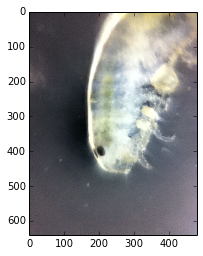

In [12]:
imshow(sitk.GetArrayFromImage(input_image));

Meet our Friend, the Talitrus Saltrator:

http://en.wikipedia.org/wiki/Talitrus_saltator

### Process the Image

Note that this is a color image. That is, it has multiple components per pixel. Let's see how many:

In [13]:
print(input_image.GetNumberOfComponentsPerPixel())

3


Therefore, for some of the processing, we want to convert it into an image of Scalar values, to have a single value per pixel. We can do this with the VectorMagnitudeImageFilter. Note that a more formal way to do this would have been to use a computation of Luminance.

In [14]:
magnitude = sitk.VectorMagnitudeImageFilter()
magnitude_image = magnitude.Execute(input_image)

The same can be done with the more compact expression

In [15]:
magnitude_image = sitk.VectorMagnitude(input_image)

We can confirm that the image has now a single component

In [16]:
print(magnitude_image.GetNumberOfComponentsPerPixel())

1


And we can display this new image

In [17]:
imshow(sitk.GetArrayFromImage(magnitude_image));

By default, the imshow() functions use a rainbow colormap. We can replace it with a Grayscale colormap.

In [18]:
imshow(sitk.GetArrayFromImage(magnitude_image),cmap=cm.Greys);

Or we could use a Reverse Grayscale colormap: "Greys_r" instead of "Greys".

We can find more colormaps at:

http://wiki.scipy.org/Cookbook/Matplotlib/Show_colormap

### Extracting a feature

Let's segment the eye of our little Saltritus friend.

We can do that directly from the original color image, by using the VectorConfidenceConnected filter.

This has been aggregated in the "eyesize" helper module and can be used as follows


In [19]:
import eyesize

estimator = eyesize.EyeSize()

estimator.set_image(input_image)
estimator.set_seed_point([204,400])

eyes_segmented,radius_estimate = estimator.estimate()

We now display the resulting segmentation

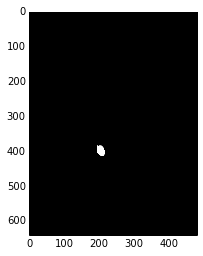

In [20]:
imshow(sitk.GetArrayFromImage(eyes_segmented),cmap=cm.gray);

We can overlay the two images to get a better sense of the segmentation quality

In [21]:
magnitude_image = sitk.VectorMagnitude(input_image)
image_overlay = sitk.LabelOverlay(magnitude_image, eyes_segmented)
imshow(sitk.GetArrayFromImage(image_overlay),cmap=cm.gray);

## Exercise

1. Replace the code in the above cell with the `overlay_segmentation` function from the *eyesize* module.
2. Optionally run the analysis on one of the images that you collected. If your creature is much smaller than our Saltritus friend, try segmenting the entire creature instead of its eye.